In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.utils import  energy2wavelength
from temgym_core.gaussian import make_gaussian_plane_wave_round_aperture
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_jax_scan
from temgym_core.gaussian_taylor import (
    Lens,
    SigmoidAperture,
    run_to_end,

)

jax.config.update("jax_enable_x64", True)

In [2]:
voltage = 300000  # in volts
wavelength = energy2wavelength(voltage)  # in meters
input_window_width = 1e-6
aperture_radius = 0.1e-6
aperture_window_width = input_window_width
lens_f = 1e-2

Nx = Ny = 256
input_aperture_pixel_size_x = input_window_width/Nx
input_aperture_pixel_size_y = input_window_width/Ny

output_aperture_pixel_size_bfp_xy = wavelength * abs(lens_f) / (aperture_window_width)

input_aperture_grid = Detector(z=0.0, pixel_size=(input_aperture_pixel_size_x, input_aperture_pixel_size_y), shape=(Nx, Ny))

input_extent = input_aperture_grid.extent

aperture = SigmoidAperture(radius=aperture_radius, sharpness=1000, z=0.0, t_outside=0.0)

In [3]:
rays_in, wavelength, k0 = make_gaussian_plane_wave_round_aperture(
    voltage=voltage,
    aperture_radius=aperture.radius,
    waist_radius=5e-9,
    num_rays=50000,
    normalization='flux',
)
rays_in = rays_in.to_vector()

# Create JIT-ed single-ray and VMAP-ed batched versions without overwriting the original
run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)


In [4]:
rays_out = run_to_end_vmapped(rays_in, (aperture,))
input_aperture_image =  evaluate_gaussians_gpu_kernel_wrapper(rays_out, input_aperture_grid).block_until_ready()

In [5]:
lens = Lens(z=lens_f, focal_length=lens_f)
output_probe_grid = Detector(z=lens_f * 2, pixel_size=(output_aperture_pixel_size_bfp_xy, output_aperture_pixel_size_bfp_xy), shape=(Nx, Ny))
output_extent = output_probe_grid.extent
output_x, output_y = output_probe_grid.coords_1d

components = (aperture, lens, output_probe_grid)
rays_out = run_to_end_vmapped(rays_in, components)

In [6]:
probe_image = evaluate_gaussians_gpu_kernel_wrapper(rays_out, output_probe_grid).block_until_ready()

In [7]:
du, dv = input_aperture_pixel_size_x, input_aperture_pixel_size_y
diffraction_of_aperture = jnp.fft.ifftshift(jnp.fft.fft2(input_aperture_image)) * (du * dv) / (1j * wavelength * lens_f) # Very important energy conservation factor
det_image_in_focus = jnp.abs(diffraction_of_aperture)

Text(0.5, 1.0, 'Input Aperture Intensity')

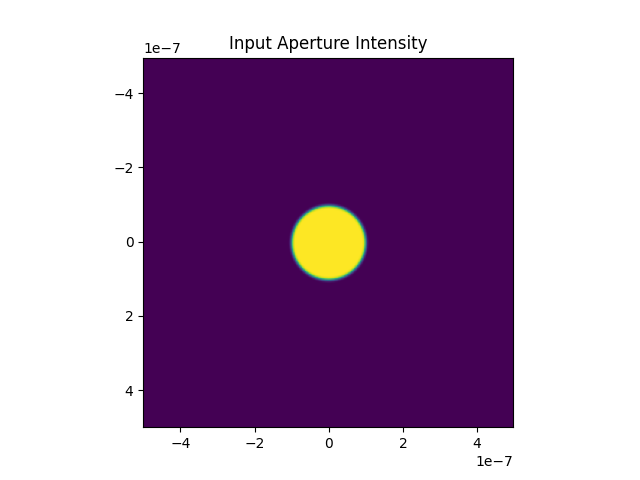

In [8]:
plt.figure()
plt.imshow(jnp.abs(input_aperture_image), extent=input_extent)
plt.title('Input Aperture Intensity')

Text(0.5, 1.0, 'Diffraction of Aperture (a.u.)')

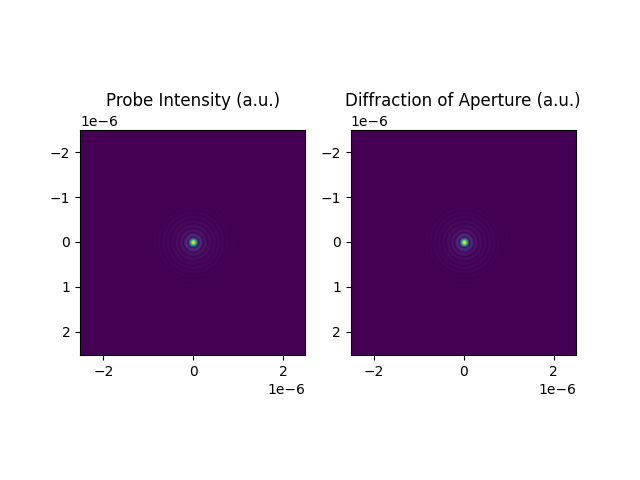

In [9]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(jnp.abs(probe_image), extent=output_extent)
ax[0].set_title('Probe Intensity (a.u.)')
ax[1].imshow(jnp.abs(det_image_in_focus), extent=output_extent)
ax[1].set_title('Diffraction of Aperture (a.u.)')

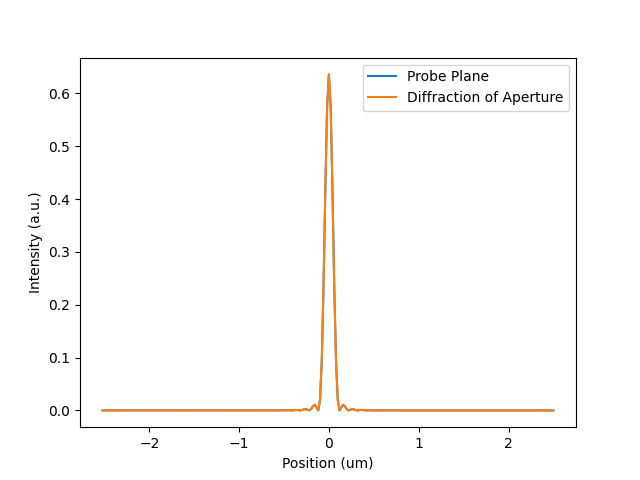

In [10]:
plt.figure()
plt.plot(output_x*1e6, jnp.abs(probe_image[Nx//2,:])**2, label='Probe Plane')
plt.plot(output_x*1e6, jnp.abs(det_image_in_focus[Nx//2,:])**2, label='Diffraction of Aperture')
plt.xlabel('Position (um)')
plt.ylabel('Intensity (a.u.)')
plt.legend()